## Clustering in Practice
- ✅Apply K-Means with k-means++ initialization
- ✅Determine optimal clusters using elbow method and silhouetee scores
- ✅Use DBSCAN for density-based clustering with noise handling
- ✅Visualize high-dimensional clusters using PCA
- ✅Compare algorithmic approoches for different data characteristics

In [2]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.datasets import make_blobs, make_moons
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

print('✅ Libraries imported successfully')

✅ Libraries imported successfully


In [3]:
# Generate synthetic customer data with distinct segments
np.random.seed(42)

# Create 5 natural customer segments
# Low income, low spending
segment1 = np.random.randn(40, 2) * [5, 10] + [30, 30]

# Low income, high spending
segment2 = np.random.randn(40, 2) * [5, 10] + [30, 75]

# Medium income, medium spending
segment3 = np.random.randn(50, 2) * [8, 12] + [60, 50]

# High income, low spending
segment4 = np.random.randn(40, 2) * [6, 10] + [85, 30]

# High income, high spending
segment5 = np.random.randn(40, 2) * [6, 10] + [85, 75]

# Add some noise points (outliers)
noise = np.random.uniform(low=[20, 10], high=[100, 90], size=(10, 2))

# Combine all segments
X = np.vstack([segment1, segment2, segment3, segment4, segment5, noise])

# Create DataFrame
df = pd.DataFrame(X, columns=['Annual_Income_k$', 'Spending_Score'])

print(f'✅ Generated {len(df)} customer records')
print(f'Features: {list(df.columns)}')
df.head()

✅ Generated 220 customer records
Features: ['Annual_Income_k$', 'Spending_Score']


,Annual_Income_k$,Spending_Score
0,32.483571,28.617357
1,33.238443,45.230299
2,28.829233,27.658630
3,37.896064,37.674347
4,27.652628,35.425600


In [4]:
# Display summary statistics
print('📊 Dataset Summary Statistics:')
print(df.describe())

print('\n📋 Data Info:')
print(df.info())

print('\n🔍 Missing Values:')
print(df.isnull().sum())

📊 Dataset Summary Statistics:
       Annual_Income_k$  Spending_Score
count        220.000000      220.000000
mean          58.372213       51.911909
std           25.239782       22.796532
min           16.901274       10.124311
25%           31.278930       31.612114
50%           60.415122       54.358816
75%           84.145157       71.737380
max           98.138818       99.632421

📋 Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Annual_Income_k$  220 non-null    float64
 1   Spending_Score    220 non-null    float64
dtypes: float64(2)
memory usage: 3.6 KB
None

🔍 Missing Values:
Annual_Income_k$    0
Spending_Score      0
dtype: int64


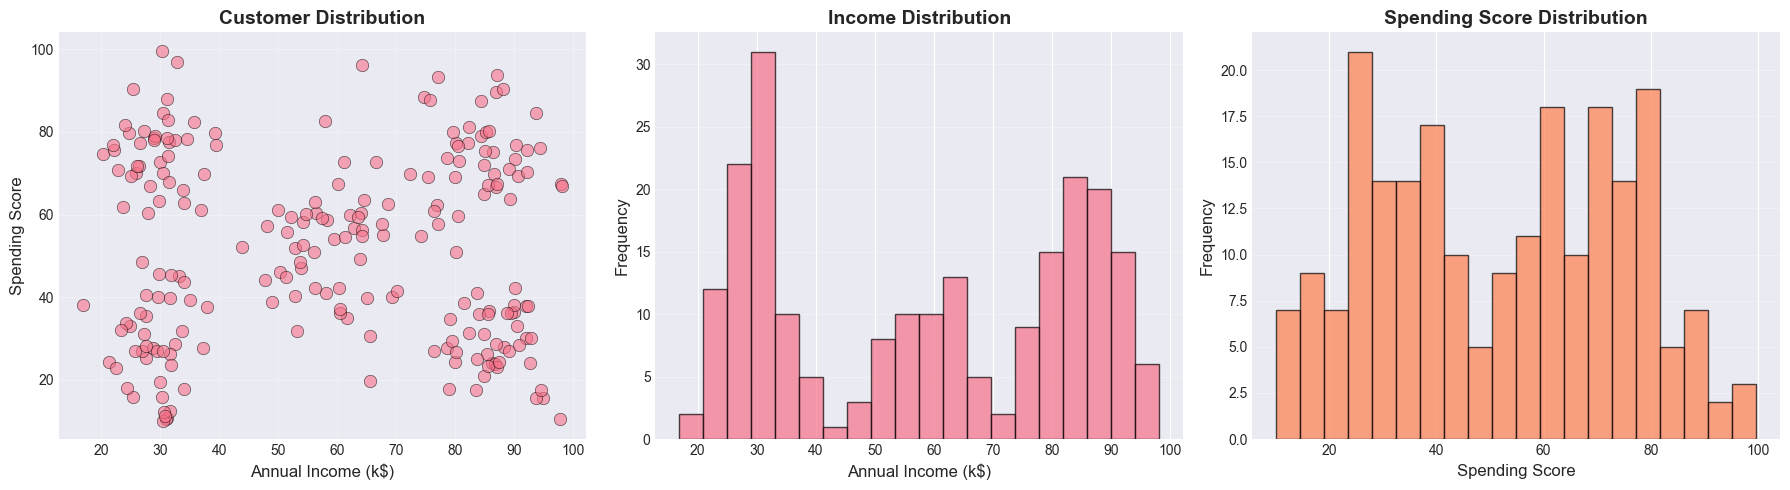


💡 Observation: The scatter plot suggests multiple distinct customer groups!


In [5]:
# Visualize the raw data distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scatter plot
axes[0].scatter(df['Annual_Income_k$'], df['Spending_Score'],
                alpha=0.6, s=80, edgecolors='black', linewidth=0.5)
axes[0].set_xlabel('Annual Income (k$)', fontsize=12)
axes[0].set_ylabel('Spending Score', fontsize=12)
axes[0].set_title('Customer Distribution', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Income distribution
axes[1].hist(df['Annual_Income_k$'], bins=20, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Annual Income (k$)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Income Distribution', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

# Spending score distribution
axes[2].hist(df['Spending_Score'], bins=20, edgecolor='black', alpha=0.7, color='coral')
axes[2].set_xlabel('Spending Score', fontsize=12)
axes[2].set_ylabel('Frequency', fontsize=12)
axes[2].set_title('Spending Score Distribution', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3, axis='y')


plt.tight_layout()
plt.show()

print('\n💡 Observation: The scatter plot suggests multiple distinct customer groups!')

In [6]:
# Standardize features (critical for distance-based algorithms)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

print('✅ Features standardized (zero mean, unit variance)')
print(f'Original data shape: {df.shape}')
print(f'Scaled data shape: {X_scaled.shape}')
print(f'\nScaled data mean: {X_scaled.mean(axis=0)}')
print(f'Scaled data std: {X_scaled.std(axis=0)}')

✅ Features standardized (zero mean, unit variance)
Original data shape: (220, 2)
Scaled data shape: (220, 2)

Scaled data mean: [ 1.78771139e-15 -1.37314402e-15]
Scaled data std: [1. 1.]


In [7]:
# Elbow Method

wcss = []
k_range = range(2,11)

for k in k_range:
  kmeans = KMeans(n_clusters=k,init="k-means++",random_state=42)
  kmeans.fit(X_scaled)
  wcss.append(kmeans.inertia_)

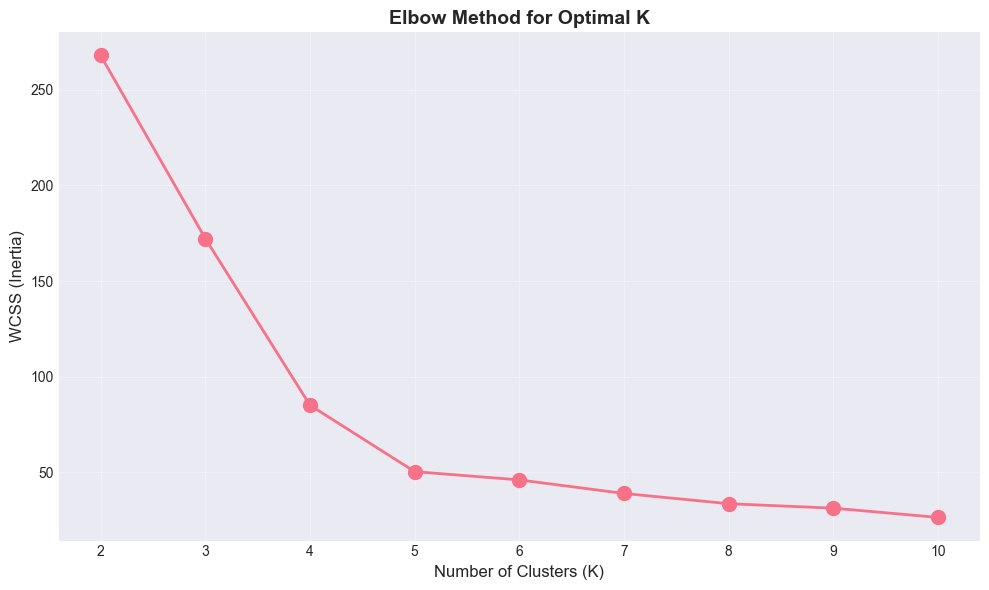

💡 Look for the "elbow" where WCSS decrease slows significantly


In [8]:
# Plot elbow curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linewidth=2, markersize=10)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('WCSS (Inertia)', fontsize=12)
plt.title('Elbow Method for Optimal K', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(k_range)
plt.tight_layout()
plt.show()

print('💡 Look for the "elbow" where WCSS decrease slows significantly')

In [9]:
silhouette_scores = []

for k in range(2,11):
  kmeans = KMeans(n_clusters=k,init="k-means++",random_state=42)
  labels = kmeans.fit_predict(X_scaled)
  score = silhouette_score(X_scaled,labels)
  silhouette_scores.append(score)

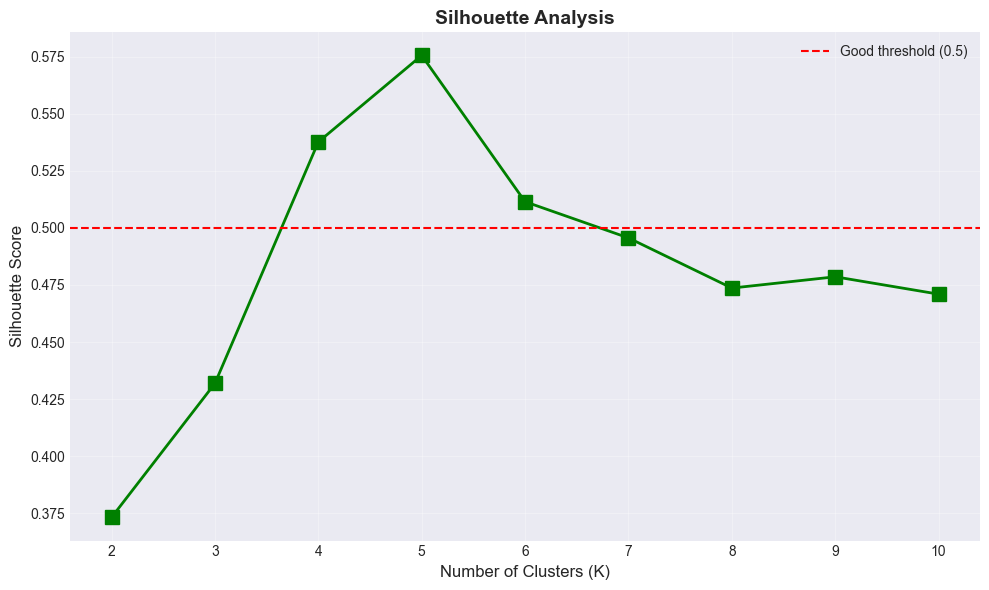


✅ Optimal K based on silhouette score: 5


In [10]:
# Plot silhouette scores
plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), silhouette_scores, marker='s', linewidth=2,
         markersize=10, color='green')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Analysis', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(range(2, 11))
plt.axhline(y=0.5, color='red', linestyle='--', label='Good threshold (0.5)')
plt.legend()
plt.tight_layout()
plt.show()

optimal_k = silhouette_scores.index(max(silhouette_scores)) + 2
print(f'\n✅ Optimal K based on silhouette score: {optimal_k}')

In [11]:
#fit kmeans with most optimised values
k = 5

kmeans = KMeans(n_clusters=k,init="k-means++",random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Add cluster labels to dataframe
df['KMeans_Cluster'] = kmeans_labels

print(f'✅ K-Means clustering completed with K={optimal_k}')
print(f'Cluster distribution:')
print(df['KMeans_Cluster'].value_counts().sort_index())

# Calculate final silhouette score
final_silhouette = silhouette_score(X_scaled, kmeans_labels)
print(f'\nFinal Silhouette Score: {final_silhouette:.3f}')

✅ K-Means clustering completed with K=5
Cluster distribution:
KMeans_Cluster
0    48
1    40
2    42
3    44
4    46
Name: count, dtype: int64

Final Silhouette Score: 0.576


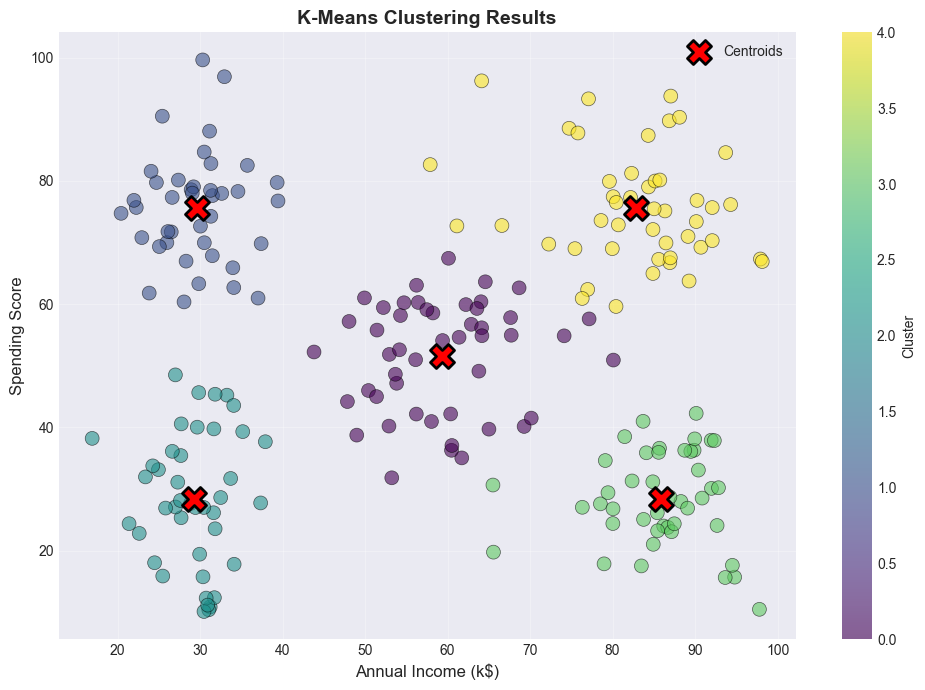

In [12]:
# Visualize K-Means clusters
plt.figure(figsize=(10, 7))
scatter = plt.scatter(df['Annual_Income_k$'], df['Spending_Score'],
                      c=kmeans_labels, cmap='viridis',
                      s=100, alpha=0.6, edgecolors='black', linewidth=0.5)

# Plot centroids
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids[:, 0], centroids[:, 1],
            c='red', s=300, marker='X', edgecolors='black', linewidth=2,
            label='Centroids')

plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score', fontsize=12)
plt.title('K-Means Clustering Results', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

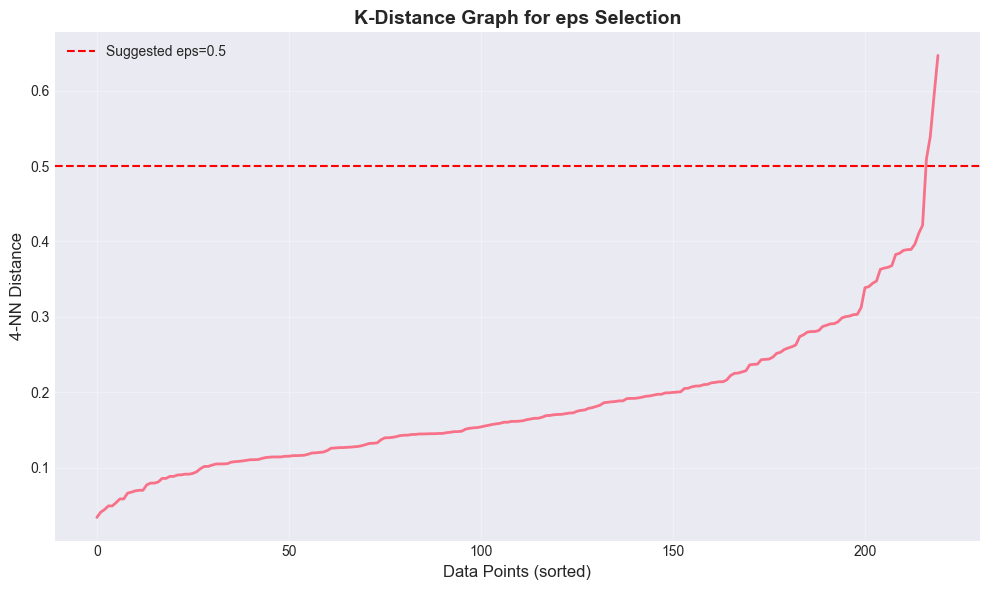

💡 The elbow point in this curve suggests the optimal eps value
💡 eps should be slightly above where the curve starts rising sharply


In [13]:
from sklearn.neighbors import NearestNeighbors

# Use min_samples = 2 * dimensionality = 2 * 2 = 4

from sklearn.neighbors import NearestNeighbors

# Use min_samples = 2 * dimensionality = 2 * 2 = 4
min_samples = 4

# Compute k-nearest neighbors
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors.fit(X_scaled)
distances, indices = neighbors.kneighbors(X_scaled)

# Sort distances to 4th nearest neighbor
distances = np.sort(distances[:, -1], axis=0)

# Plot k-distance graph
plt.figure(figsize=(10, 6))
plt.plot(distances, linewidth=2)
plt.xlabel('Data Points (sorted)', fontsize=12)
plt.ylabel(f'{min_samples}-NN Distance', fontsize=12)
plt.title('K-Distance Graph for eps Selection', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.axhline(y=0.5, color='red', linestyle='--', label='Suggested eps=0.5')
plt.legend()
plt.tight_layout()
plt.show()

print('💡 The elbow point in this curve suggests the optimal eps value')
print('💡 eps should be slightly above where the curve starts rising sharply')

In [14]:
silhouette_scores = []

for k in range(2,11):
  kmeans = KMeans(n_clusters=k,init="k-means++",random_state=42)
  labels = kmeans.fit_predict(X_scaled)
  score = silhouette_score(X_scaled,labels)
  silhouette_scores.append(score)

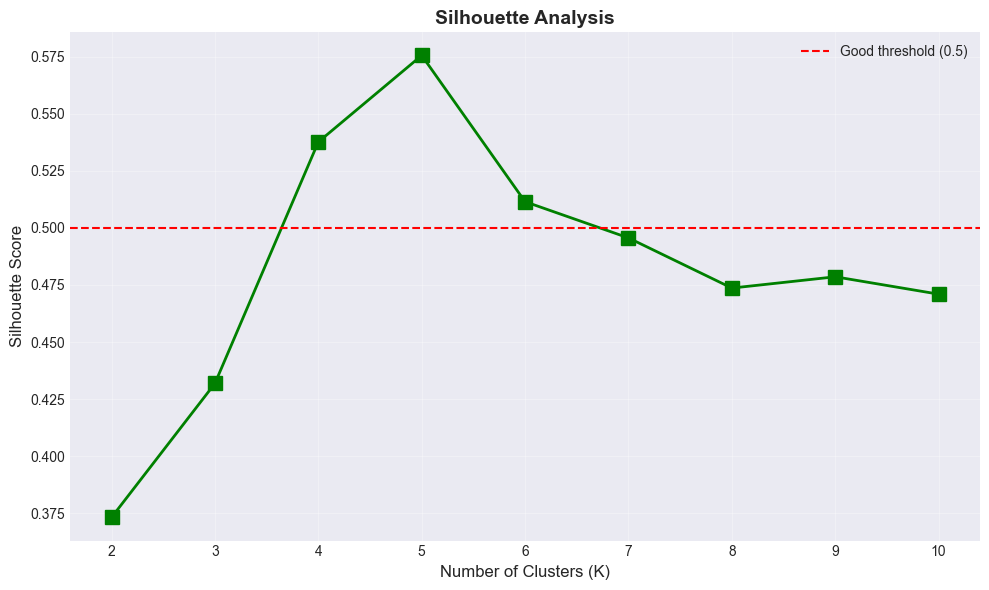


✅ Optimal K based on silhouette score: 5


In [15]:
# Plot silhouette scores
plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), silhouette_scores, marker='s', linewidth=2,
         markersize=10, color='green')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Analysis', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(range(2, 11))
plt.axhline(y=0.5, color='red', linestyle='--', label='Good threshold (0.5)')
plt.legend()
plt.tight_layout()
plt.show()

optimal_k = silhouette_scores.index(max(silhouette_scores)) + 2
print(f'\n✅ Optimal K based on silhouette score: {optimal_k}')

In [16]:
# Fit K-Means with optimal K
optimal_k = 5  # Based on analysis above
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Add cluster labels to dataframe
df['KMeans_Cluster'] = kmeans_labels

print(f'✅ K-Means clustering completed with K={optimal_k}')
print(f'Cluster distribution:')
print(df['KMeans_Cluster'].value_counts().sort_index())

# Calculate final silhouette score
final_silhouette = silhouette_score(X_scaled, kmeans_labels)
print(f'\nFinal Silhouette Score: {final_silhouette:.3f}')

✅ K-Means clustering completed with K=5
Cluster distribution:
KMeans_Cluster
0    48
1    40
2    42
3    44
4    46
Name: count, dtype: int64

Final Silhouette Score: 0.576


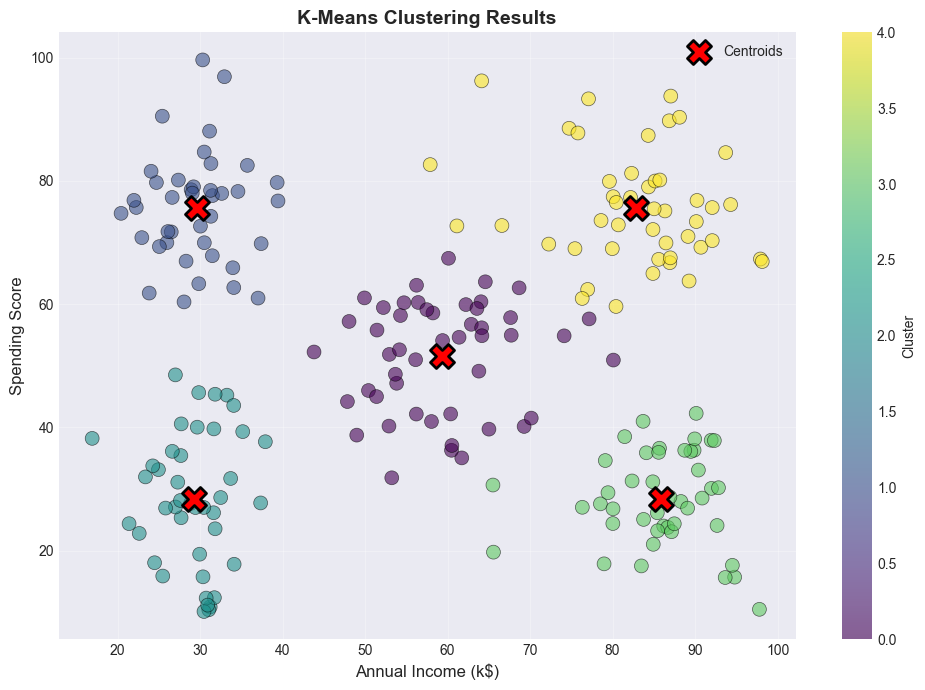

In [17]:
# Visualize K-Means clusters
plt.figure(figsize=(10, 7))
scatter = plt.scatter(df['Annual_Income_k$'], df['Spending_Score'],
                      c=kmeans_labels, cmap='viridis',
                      s=100, alpha=0.6, edgecolors='black', linewidth=0.5)

# Plot centroids
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids[:, 0], centroids[:, 1],
            c='red', s=300, marker='X', edgecolors='black', linewidth=2,
            label='Centroids')

plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score', fontsize=12)
plt.title('K-Means Clustering Results', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

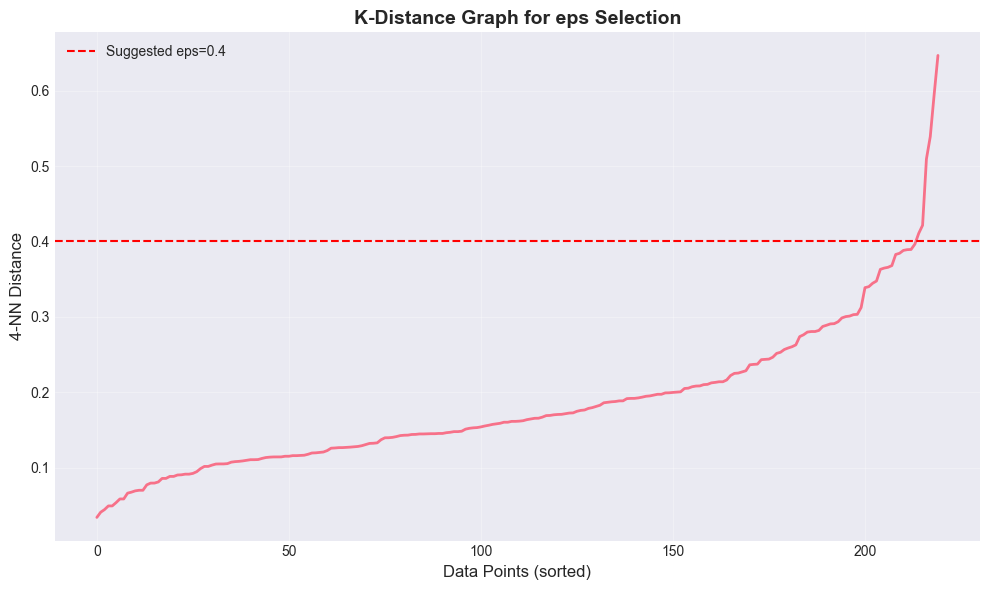

💡 The elbow point in this curve suggests the optimal eps value
💡 eps should be slightly above where the curve starts rising sharply


In [18]:
from sklearn.neighbors import NearestNeighbors

min_samples = 4

# no of samples = 2 * Dimension

# Compute k-nearest neighbors
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors.fit(X_scaled)
distances, indices = neighbors.kneighbors(X_scaled)
#print(distances,indices)

# Sort distances to 4th nearest neighbor
distances = np.sort(distances[:, -1], axis=0)

# Plot k-distance graph
plt.figure(figsize=(10, 6))
plt.plot(distances, linewidth=2)
plt.xlabel('Data Points (sorted)', fontsize=12)
plt.ylabel(f'{min_samples}-NN Distance', fontsize=12)
plt.title('K-Distance Graph for eps Selection', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.axhline(y=0.4, color='red', linestyle='--', label='Suggested eps=0.4')
plt.legend()
plt.tight_layout()
plt.show()

print('💡 The elbow point in this curve suggests the optimal eps value')
print('💡 eps should be slightly above where the curve starts rising sharply')

In [19]:
#apply DBSCAN

eps = 0.4
min_samples = 4

dbscan = DBSCAN(eps=eps,min_samples= min_samples)
dbscan_labels = dbscan.fit_predict(X_scaled)

#[0,1,-1,2,-1,0]

#Add labels to dataframe
df['DBSCAN_Cluster'] = dbscan_labels

# Count clusters and noise
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f'✅ DBSCAN clustering completed')
print(f'eps={eps}, min_samples={min_samples}')
print(f'\nNumber of clusters: {n_clusters}')
print(f'Number of noise points: {n_noise} ({n_noise/len(df)*100:.1f}%)')
print(f'\nCluster distribution:')
print(df['DBSCAN_Cluster'].value_counts().sort_index())

# Silhouette score (excluding noise points)
if n_clusters > 1:
    mask = dbscan_labels != -1
    if sum(mask) > 0:
        dbscan_silhouette = silhouette_score(X_scaled[mask], dbscan_labels[mask])
        print(f'\nSilhouette Score (excluding noise): {dbscan_silhouette:.3f}')

✅ DBSCAN clustering completed
eps=0.4, min_samples=4

Number of clusters: 4
Number of noise points: 4 (1.8%)

Cluster distribution:
DBSCAN_Cluster
-1     4
 0    42
 1    39
 2    93
 3    42
Name: count, dtype: int64

Silhouette Score (excluding noise): 0.525


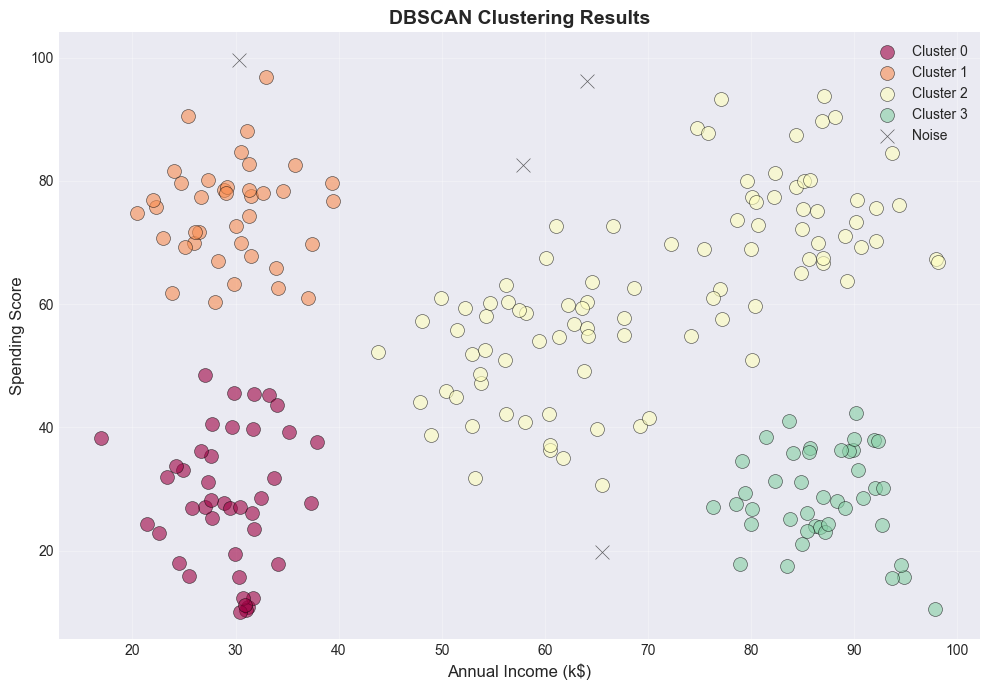


💡 Note: Black X markers represent noise points (outliers)


In [20]:
# Visualize DBSCAN clusters
plt.figure(figsize=(10, 7))

# Separate noise points
core_samples_mask = np.zeros_like(dbscan_labels, dtype=bool)
core_samples_mask[dbscan.core_sample_indices_] = True

unique_labels = set(dbscan_labels)
colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Noise points in black
        col = 'black'
        marker = 'x'
        label = 'Noise'
    else:
        marker = 'o'
        label = f'Cluster {k}'

    class_member_mask = (dbscan_labels == k)
    xy = df.loc[class_member_mask, ['Annual_Income_k$', 'Spending_Score']].values

    plt.scatter(xy[:, 0], xy[:, 1], c=[col], marker=marker,
                s=100, alpha=0.6, edgecolors='black', linewidth=0.5,
                label=label)

plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score', fontsize=12)
plt.title('DBSCAN Clustering Results', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\n💡 Note: Black X markers represent noise points (outliers)')

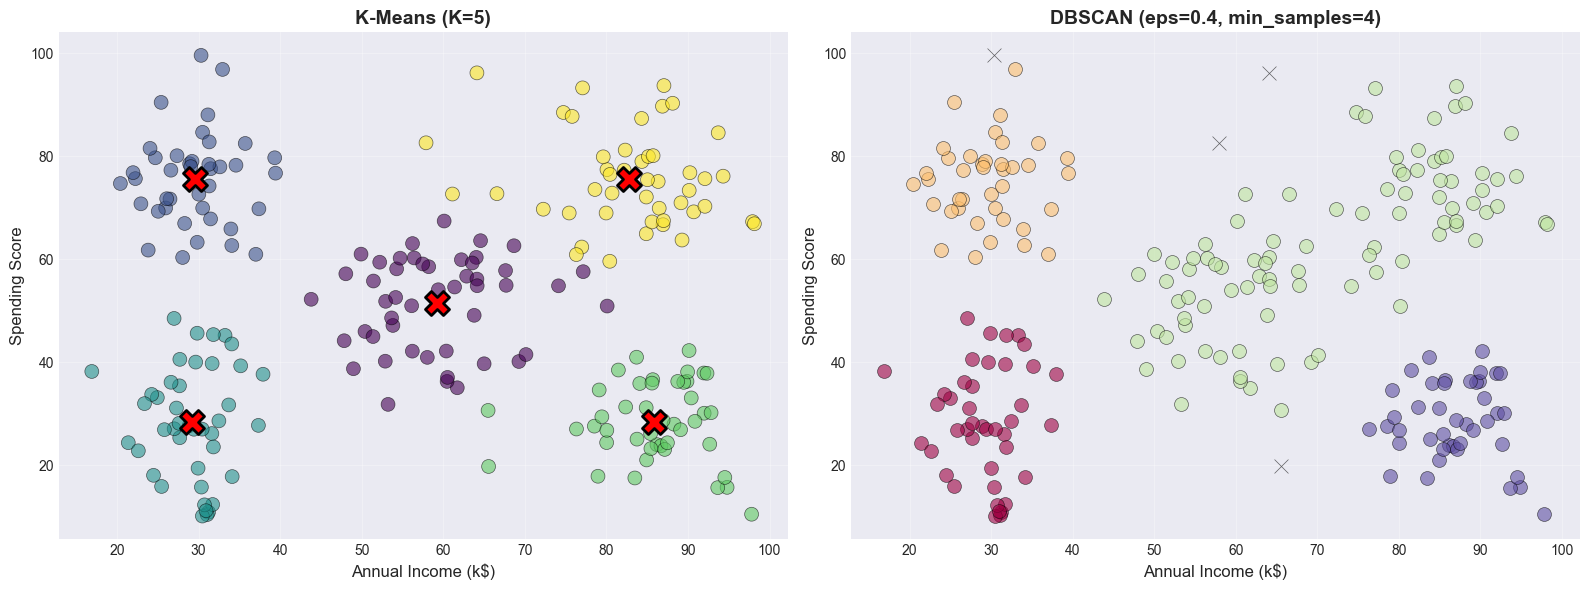

In [21]:
# Side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# K-Means
scatter1 = axes[0].scatter(df['Annual_Income_k$'], df['Spending_Score'],
                           c=df['KMeans_Cluster'], cmap='viridis',
                           s=100, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[0].scatter(centroids[:, 0], centroids[:, 1],
                c='red', s=300, marker='X', edgecolors='black', linewidth=2)
axes[0].set_xlabel('Annual Income (k$)', fontsize=12)
axes[0].set_ylabel('Spending Score', fontsize=12)
axes[0].set_title(f'K-Means (K={optimal_k})', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# DBSCAN
for k in set(dbscan_labels):
    if k == -1:
        col = 'black'
        marker = 'x'
    else:
        col = plt.cm.Spectral(k / max(set(dbscan_labels)))
        marker = 'o'

    mask = (dbscan_labels == k)
    axes[1].scatter(df.loc[mask, 'Annual_Income_k$'],
                    df.loc[mask, 'Spending_Score'],
                    c=[col], marker=marker, s=100, alpha=0.6,
                    edgecolors='black', linewidth=0.5)

axes[1].set_xlabel('Annual Income (k$)', fontsize=12)
axes[1].set_ylabel('Spending Score', fontsize=12)
axes[1].set_title(f'DBSCAN (eps={eps}, min_samples={min_samples})',
                  fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f'✅ PCA applied: {X_scaled.shape} → {X_pca.shape}')
print(f'Explained variance ratio: {pca.explained_variance_ratio_}')
print(f'Total variance preserved: {sum(pca.explained_variance_ratio_)*100:.1f}%')

✅ PCA applied: (220, 2) → (220, 2)
Explained variance ratio: [0.50280851 0.49719149]
Total variance preserved: 100.0%


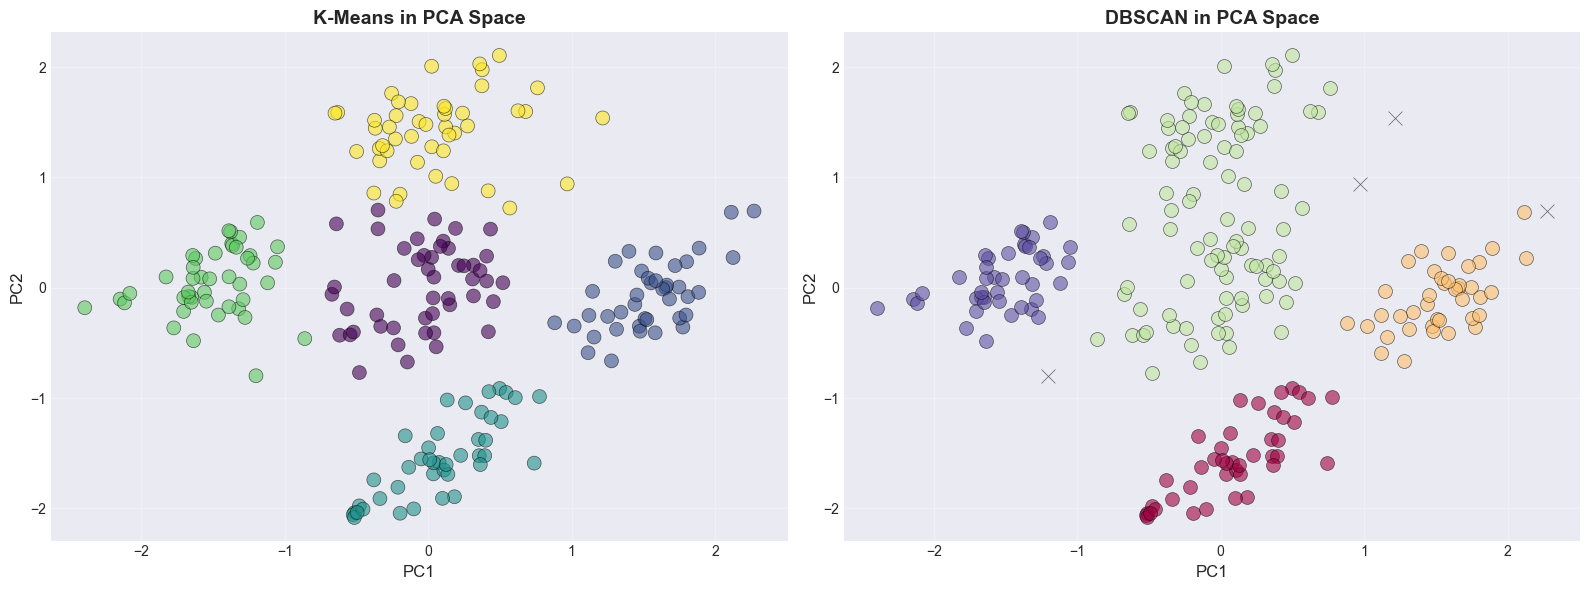

In [23]:
# Visualize in PCA space
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# K-Means in PCA space
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels,
                cmap='viridis', s=100, alpha=0.6,
                edgecolors='black', linewidth=0.5)
axes[0].set_xlabel('PC1', fontsize=12)
axes[0].set_ylabel('PC2', fontsize=12)
axes[0].set_title('K-Means in PCA Space', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# DBSCAN in PCA space
for k in set(dbscan_labels):
    if k == -1:
        col = 'black'
        marker = 'x'
    else:
        col = plt.cm.Spectral(k / max(set(dbscan_labels)))
        marker = 'o'

    mask = (dbscan_labels == k)
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=[col], marker=marker, s=100, alpha=0.6,
                    edgecolors='black', linewidth=0.5)

axes[1].set_xlabel('PC1', fontsize=12)
axes[1].set_ylabel('PC2', fontsize=12)
axes[1].set_title('DBSCAN in PCA Space', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

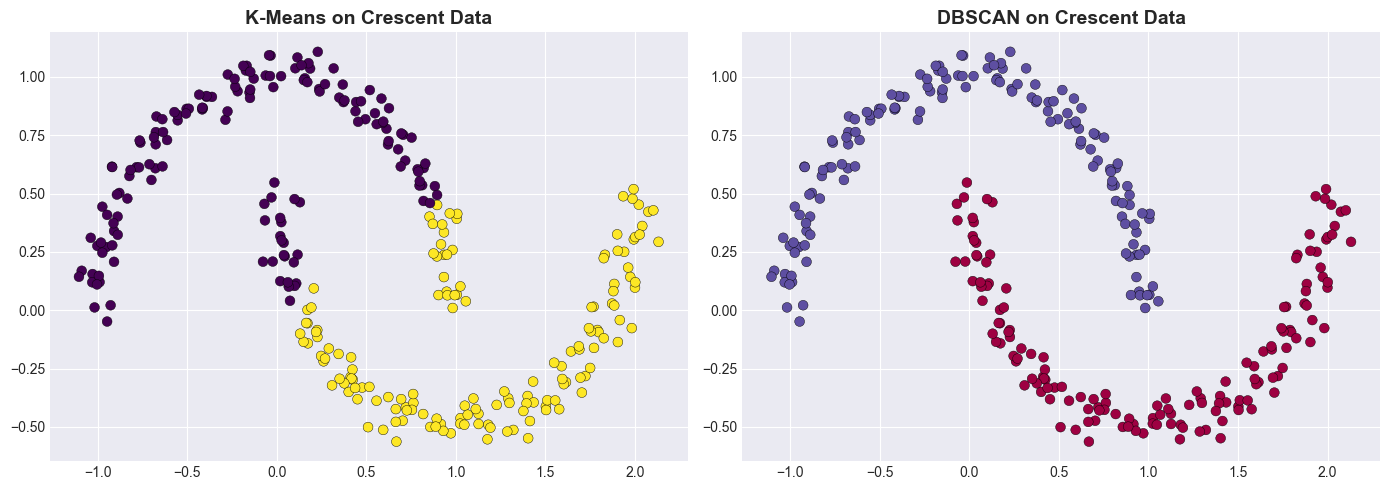

In [24]:
#experimentation

from sklearn.datasets import make_moons

X_moons, _ = make_moons(n_samples=300, noise=0.05, random_state=42)
X_moons_scaled = StandardScaler().fit_transform(X_moons)

kmeans_moons = KMeans(n_clusters=2, random_state=42)
kmeans_moons_labels = kmeans_moons.fit_predict(X_moons_scaled)

dbscan_moons = DBSCAN(eps=0.3, min_samples=5)
dbscan_moons_labels = dbscan_moons.fit_predict(X_moons_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_moons[:, 0], X_moons[:, 1], c=kmeans_moons_labels,
                cmap='viridis', s=50, edgecolors='black', linewidth=0.3)
axes[0].set_title('K-Means on Crescent Data', fontsize=14, fontweight='bold')

axes[1].scatter(X_moons[:, 0], X_moons[:, 1], c=dbscan_moons_labels,
                cmap='Spectral', s=50, edgecolors='black', linewidth=0.3)
axes[1].set_title('DBSCAN on Crescent Data', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()